# The Gridbreaker — Sales Forecasting Pipeline
## Phần 3: Mô hình Dự báo Doanh thu (Sales Forecasting)

**Datathon 2026 — Round 1**

---

### Tổng quan Pipeline

```
Raw Sales --> [1. Denoising] --> [2. Prophet] --> [3. CatBoost Residual] --> [4. Blend] --> Forecast
                  |                    |                    |
             outlier capping       trend+seasonal      lag365/730 + calendar
             (no stockout)         Clean_Revenue       fill_rate, overstock_pct, sessions
```

**Nguồn dùng chung (single source):** Toàn bộ logic mô hình nằm trong gói `src/`
(giống `pipeline.py`). Notebook này chỉ *gọi* các hàm từ `src` — không định nghĩa
lại — nên kết quả luôn đồng bộ với pipeline production.

**Kiến trúc tầng residual:** Tầng 2 dùng **CatBoost** (cây đối xứng, nông `depth=3`)
làm mô hình **chốt** vì bền bỉ hơn trước độ nhiễu của phần dư trong dự báo cuốn
2 năm. **LightGBM** được giữ làm **mô hình phụ** để đối chứng (Bước 4b). Optuna
được minh hoạ trên không gian CatBoost (Bước 4a).

**Ràng buộc tuân thủ:**
1. Không dùng dữ liệu ngoài bộ dữ liệu cung cấp
2. Tất cả features là future-safe (không data leakage, lag $\geq$ 365 ngày)
3. Random seed = 42 (reproducibility)
4. COGS <= Revenue

In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ROOT = os.path.abspath(os.path.join(os.path.dirname("__file__"), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

CSV_DIR = os.path.join(ROOT, "csv")
SEED = 42
np.random.seed(SEED)

TRAIN_END  = "2021-12-31"
VAL_START  = "2022-01-01"
VAL_END    = "2022-12-31"
TEST_START = "2023-01-01"
TEST_END   = "2024-07-01"

---
## Bước 1: Load & Denoise Target

**Kiểm chứng dữ liệu (PH1 — 2026-06-19):**
`stockout_flag` tổng hợp tháng-SKU là hằng số ~67% (126/126 tháng > 0.5) → phi tín hiệu,
**KHÔNG dùng để impute target**.

**Giải pháp hiện tại:**
- Outlier capping: Cap spike > mean + 3σ trong cửa sổ 30 ngày, bảo tồn recurring spikes (≥70% số năm)
- Không stockout imputation
- Tín hiệu tồn kho thực (`fill_rate`, `overstock_pct`, `days_of_supply`) → feature lag365 trong CatBoost

In [2]:
from src.utils import load_sales
from src.denoising import denoise_target

df = load_sales(os.path.join(CSV_DIR, "sales.csv"))
df = denoise_target(df)  # outlier capping only — no stockout imputation (PH1)

# Load raw CSV cho exog regressors (dùng ở bước CatBoost bên dưới)
_inv_raw = pd.read_csv(os.path.join(CSV_DIR, "inventory.csv"))
_wt_raw = pd.read_csv(os.path.join(CSV_DIR, "web_traffic.csv"), parse_dates=["date"])

train = df.loc[:TRAIN_END]
print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} rows)")
print(f"Revenue mean: {train['Revenue'].mean()/1e6:.2f}M -> Clean: {train['Clean_Revenue'].mean()/1e6:.2f}M")

Train: 2013-01-01 -> 2021-12-31 (3287 rows)
Revenue mean: 4.42M -> Clean: 4.42M


## Bước 2: Prophet — Baseline Cấu trúc

Prophet học 3 thành phần:
- **Trend:** Xu hướng dài hạn (changepoint_prior_scale=0.15, changepoint_range=0.9)
- **Yearly seasonality:** Chu kỳ năm (Fourier, multiplicative)
- **Weekly seasonality:** Chu kỳ tuần
- **Custom holidays:** 6 chuỗi khuyến mãi tất định (Spring/Mid-Year/Fall/Year-End mỗi năm; Urban Blowout/Rural chỉ năm lẻ)

In [3]:
from src.prophet_model import fit_prophet, predict_prophet

full_idx = pd.date_range(df.index.min(), TEST_END)
results = {}

for target in ["Revenue"]:
    print(f"\n{'='*50}")
    print(f"TARGET: {target}")
    print(f"{'='*50}")

    clean_col = f"Clean_{target}"
    train_series = train[clean_col].dropna()

    # Fit Prophet
    prophet_model = fit_prophet(train_series, target_name=target)
    prophet_preds = predict_prophet(prophet_model, str(df.index.min().date()), TEST_END)

    results[target] = {"prophet_preds": prophet_preds, "prophet_model": prophet_model}
    print(f"  Prophet fitted: {len(train_series)} datapoints")


TARGET: Revenue


10:57:30 - cmdstanpy - INFO - Chain [1] start processing
10:57:30 - cmdstanpy - INFO - Chain [1] done processing


  Prophet fitted: 3287 datapoints


## Bước 3: CatBoost Residual Correction (mô hình chốt)

Tầng 2 học phần dư `Residual = Actual − Prophet_Prediction`. Mô hình chốt là
**CatBoost** với tham số thủ công `depth=3`, `iterations=300` (gọi `fit_catboost_residual`
từ `src` — chung nguồn với `pipeline.py`).

**Bộ đặc trưng (23 features, 100% future-safe, chốt sau ablation val 2022):**

| Feature | Mô tả | Tại sao an toàn? | Ablation |
|---------|-------|-----------------|----------|
| resid_lag364/365/366 | Residual cùng ngày năm ngoái | Shift 1 năm | core |
| resid_lag730 | Residual 2 năm trước (cắt compounding năm-2) | Shift 2 năm | M3.5 |
| resid_roll28_lag365 | Rolling mean 28d của lag365 | Shift 1 năm | core |
| fill_rate_lag365 | Tỷ lệ fill rate tháng năm trước | Shift 1 năm | −14.2% MAE |
| days_of_supply_lag365 | Số ngày cung tháng năm trước | Shift 1 năm | −11.8% MAE |
| overstock_pct_lag365 | % overstock tháng năm trước | Shift 1 năm | −7.5% MAE |
| sessions_lag365 | Web traffic ngày năm trước | Shift 1 năm | −4.8% MAE |
| fill_rate_lag730, sessions_lag730 | Mỏ neo 2 năm cho dự báo 2024 | Shift 2 năm | M3.6 |
| is_even_year, urban_expected, days_to_promo | Chu kỳ promo 2 năm (tất định) | Theo lịch | M3.7 |
| month, quarter, dayofyear, dayofweek, weekofyear, is_month_end, days_to_month_end, week_of_month | Calendar features | Tất định | core |

*(stockout_flag bị loại: hằng số ~67% mọi tháng-SKU → phi tín hiệu — PH1)*

In [4]:
from src.lgbm_model import (
    fit_catboost_residual, predict_catboost_residual,
    fit_lgbm_residual, predict_lgbm_residual,
    make_future_safe_features, FEAT_COLS, CATBOOST_PARAMS,
)
from src.postprocess import blend_forecasts, seasonal_ratio_cogs

# Build extra_regressors (future-safe via lag365) — inventory + web traffic
_inv_raw["snap"] = pd.to_datetime(
    _inv_raw["year"].astype(str) + "-" + _inv_raw["month"].astype(str) + "-01"
)
def _inv_daily(col):
    return _inv_raw.groupby("snap")[col].mean().resample("D").ffill().reindex(full_idx)

_sessions = _wt_raw.groupby("date")["sessions"].sum().reindex(full_idx)
extra_regressors = {
    "sessions":       _sessions,
    "overstock_pct":  _inv_daily("overstock_flag"),
    "days_of_supply": _inv_daily("days_of_supply"),
    "fill_rate":      _inv_daily("fill_rate"),
}

for target in ["Revenue"]:
    prophet_preds = results[target]["prophet_preds"]
    train_prophet = prophet_preds.loc[:TRAIN_END, "prophet_pred"]
    residual_train = train[target].reindex(train_prophet.index) - train_prophet

    full_residuals = pd.Series(np.nan, index=full_idx, name="residual")
    full_residuals.update(residual_train)
    full_trend = prophet_preds["prophet_trend"].reindex(full_idx)
    X_full = make_future_safe_features(full_residuals, full_trend, full_idx, extra_regressors)

    X_train = X_full.loc[:TRAIN_END]
    y_train = residual_train.reindex(X_train.index)
    cat_model = fit_catboost_residual(X_train, y_train, target_name=target)  # depth=3 thủ công

    results[target]["cat_model"] = cat_model
    results[target]["X_full"] = X_full
    results[target]["residual_train"] = residual_train

print("CatBoost (chốt) trained for Revenue.")
print(f"Params: {CATBOOST_PARAMS}")
print(f"Features used ({len(FEAT_COLS)}): {FEAT_COLS}")

CatBoost (chốt) trained for Revenue.
Params: {'iterations': 300, 'learning_rate': 0.099, 'depth': 3, 'l2_leaf_reg': 3.0, 'random_seed': 42, 'verbose': False}
Features used (23): ['resid_lag365', 'resid_lag364', 'resid_lag366', 'resid_lag730', 'resid_roll28_lag365', 'prophet_trend', 'fill_rate_lag365', 'days_of_supply_lag365', 'overstock_pct_lag365', 'sessions_lag365', 'fill_rate_lag730', 'sessions_lag730', 'is_even_year', 'urban_expected', 'days_to_promo', 'month', 'dayofweek', 'is_month_end', 'weekofyear', 'quarter', 'dayofyear', 'days_to_month_end', 'week_of_month']


## Bước 4a: Tối ưu hoá siêu tham số với Optuna (minh hoạ trên không gian CatBoost)

Để khắc phục hiện tượng Overfitting của các mô hình Tree-based, nhóm **KHÔNG** dùng
GridSearch/RandomSearch (xáo trộn dữ liệu → phá vỡ cấu trúc thời gian → rò rỉ).
Thay vào đó:
1. **TimeSeriesSplit (K-Fold=3):** Tập Validation luôn nằm ở tương lai so với Train.
2. **Optuna (TPE Sampler):** Tối ưu hóa Bayesian dò tìm thông minh bộ tham số.

**Lưu ý quan trọng (kết quả âm tính):** Optuna được chạy ở đây để *khảo sát* không
gian tham số CatBoost. Tuy nhiên, trên kiểm chứng mô phỏng đúng điều kiện production
(dự báo cuốn 2 năm), bộ tham số Optuna-tuned **overfit** kịch bản "lag365 luôn sạch"
và *kém hơn* tham số thủ công `depth=3`. Vì vậy mô hình chốt vẫn là CatBoost thủ công
(Bước 3) — đây là một lựa chọn có chủ đích vì độ bền vững, không phải vì thiếu tuning.

In [5]:
import optuna
from sklearn.model_selection import TimeSeriesSplit
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

X_tune = results["Revenue"]["X_full"].loc[:TRAIN_END].dropna()
y_tune = results["Revenue"]["residual_train"].reindex(X_tune.index).dropna()
X_tune = X_tune.reindex(y_tune.index)[FEAT_COLS]

def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth":         trial.suggest_int("depth", 3, 7),
        "l2_leaf_reg":   trial.suggest_float("l2_leaf_reg", 0.1, 10.0, log=True),
        "iterations":    300,
        "random_seed":   SEED,
        "verbose":       False,
    }
    tscv = TimeSeriesSplit(n_splits=3)
    mae_scores = []
    for tr_idx, vl_idx in tscv.split(X_tune):
        X_tr, y_tr = X_tune.iloc[tr_idx], y_tune.iloc[tr_idx]
        X_vl, y_vl = X_tune.iloc[vl_idx], y_tune.iloc[vl_idx]
        m = CatBoostRegressor(**params)
        m.fit(X_tr, y_tr)
        mae_scores.append(mean_absolute_error(y_vl, m.predict(X_vl)))
    return np.mean(mae_scores)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
print(f"Best CV MAE (residual): {study.best_value/1e6:.3f}M")
print(f"Best params (Optuna, CatBoost): {best_params}")
print(f"→ Mô hình CHỐT vẫn dùng tham số thủ công depth=3 (robust hơn trên dự báo cuốn 2 năm).")

  0%|          | 0/30 [00:00<?, ?it/s]

Best CV MAE (residual): 0.729M
Best params (Optuna, CatBoost): {'learning_rate': 0.010190602326427347, 'depth': 7, 'l2_leaf_reg': 5.247086148453273}
→ Mô hình CHỐT vẫn dùng tham số thủ công depth=3 (robust hơn trên dự báo cuốn 2 năm).


## Bước 4b: Mô hình phụ — LightGBM (đối chứng)

LightGBM được giữ làm mô hình phụ để đối chứng với CatBoost trên cùng tập đặc trưng.
LightGBM dùng cơ chế **dừng sớm (early stopping) 50 vòng** trên tập validation 2022.
Trên kiểm chứng tĩnh năm 2022, hai mô hình cho kết quả tương đương; CatBoost được
chọn làm lõi vì bền vững hơn ở năm thứ 2 của dự báo cuốn (xem Chương 7 báo cáo).

In [6]:
# Fit LightGBM phụ (early stopping trên val 2022)
X_tr_full = results["Revenue"]["X_full"].loc[:TRAIN_END]
y_tr_full = results["Revenue"]["residual_train"].reindex(X_tr_full.index)
X_val_es = results["Revenue"]["X_full"].loc[VAL_START:VAL_END].dropna()
y_val_es = (
    df.loc[VAL_START:VAL_END, "Revenue"].reindex(X_val_es.index)
    - results["Revenue"]["prophet_preds"].loc[VAL_START:VAL_END, "prophet_pred"].reindex(X_val_es.index)
).dropna()
X_val_es = X_val_es.reindex(y_val_es.index)

lgbm_model = fit_lgbm_residual(
    X_tr_full, y_tr_full, target_name="Revenue",
    eval_set=(X_val_es, y_val_es),
)
results["Revenue"]["lgbm_model"] = lgbm_model

# So sánh nhanh CatBoost (chốt) vs LightGBM (phụ) trên val 2022
val_prophet_cmp = results["Revenue"]["prophet_preds"].loc[VAL_START:VAL_END, "prophet_pred"]
X_val_cmp = results["Revenue"]["X_full"].loc[VAL_START:VAL_END]
actual_cmp = df.loc[VAL_START:VAL_END, "Revenue"].reindex(X_val_cmp.index).dropna()

for name, pred_fn, mdl in [("CatBoost (chốt)", predict_catboost_residual, cat_model),
                           ("LightGBM (phụ)", predict_lgbm_residual, lgbm_model)]:
    blended = blend_forecasts(val_prophet_cmp, pred_fn(mdl, X_val_cmp)).reindex(actual_cmp.index)
    print(f"  {name:18s}: MAE={mean_absolute_error(actual_cmp, blended)/1e6:.3f}M  "
          f"R2={r2_score(actual_cmp, blended):.4f}")

  1 NaN cells trong X_test — giữ nguyên, CatBoost tự xử lý
  1 NaN cells trong X_test — giữ nguyên NaN, để LightGBM tự xử lý


  CatBoost (chốt)   : MAE=0.636M  R2=0.7211
  LightGBM (phụ)    : MAE=0.660M  R2=0.7117


## Bước 5: Validation — Metrics trên tập dữ liệu năm 2022

**Chỉ số đánh giá chính thức (mô hình chốt CatBoost):** MAE, RMSE, R², MAPE.
COGS được suy ra qua tỷ lệ mùa vụ (parity, month) — dùng chung hàm `seasonal_ratio_cogs`
từ `src` với `pipeline.py`.

In [7]:
print(f"\n{'='*60}")
print(f"  VALIDATION RESULTS (Prophet + CatBoost)")
print(f"{'='*60}")

val_metrics = {}
for target in ["Revenue"]:
    prophet_preds = results[target]["prophet_preds"]
    cat_model = results[target]["cat_model"]
    X_full = results[target]["X_full"]

    val_prophet = prophet_preds.loc[VAL_START:VAL_END, "prophet_pred"]
    X_val = X_full.loc[VAL_START:VAL_END]
    val_resid = predict_catboost_residual(cat_model, X_val)
    val_final = blend_forecasts(val_prophet, val_resid)

    actual_val = df.loc[VAL_START:VAL_END, target].reindex(val_final.index).dropna()
    val_aligned = val_final.reindex(actual_val.index)

    mae  = mean_absolute_error(actual_val, val_aligned)
    rmse = np.sqrt(mean_squared_error(actual_val, val_aligned))
    r2   = r2_score(actual_val, val_aligned)
    mape = np.mean(np.abs((actual_val - val_aligned) / actual_val.replace(0, np.nan))) * 100

    val_metrics[target] = {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}
    print(f"\n  {target} (Prophet + CatBoost):")
    print(f"    MAE  = {mae/1e6:.3f}M VND")
    print(f"    RMSE = {rmse/1e6:.3f}M VND")
    print(f"    R2   = {r2:.4f}")
    print(f"    MAPE = {mape:.2f}%")

    results[target]["val_final"] = val_aligned
    results[target]["actual_val"] = actual_val


# COGS = Revenue_dự_báo × ratio(parity, month) — chung nguồn src.seasonal_ratio_cogs
ratio_train = (df.loc[:TRAIN_END, "COGS"] / df.loc[:TRAIN_END, "Revenue"]).clip(0.5, 1.6)
val_ratio = seasonal_ratio_cogs(ratio_train, val_aligned.index)
val_cogs = (val_aligned * val_ratio)
actual_cogs = df.loc[VAL_START:VAL_END, "COGS"].reindex(val_cogs.index).dropna()
val_cogs_aligned = val_cogs.reindex(actual_cogs.index)
mae_cogs  = mean_absolute_error(actual_cogs, val_cogs_aligned)
rmse_cogs = np.sqrt(mean_squared_error(actual_cogs, val_cogs_aligned))
r2_cogs   = r2_score(actual_cogs, val_cogs_aligned)
print(f"\n  COGS (Revenue × seasonal ratio):")
print(f"    MAE  = {mae_cogs/1e6:.3f}M VND")
print(f"    RMSE = {rmse_cogs/1e6:.3f}M VND")
print(f"    R2   = {r2_cogs:.4f}")

  1 NaN cells trong X_test — giữ nguyên, CatBoost tự xử lý



  VALIDATION RESULTS (Prophet + CatBoost)

  Revenue (Prophet + CatBoost):
    MAE  = 0.636M VND
    RMSE = 0.884M VND
    R2   = 0.7211
    MAPE = 21.73%

  COGS (Revenue × seasonal ratio):
    MAE  = 0.623M VND
    RMSE = 0.854M VND
    R2   = 0.6573


In [8]:
# TÍNH ĐIỂM PROPHET ONLY (OOS)
mae_prophet = mean_absolute_error(actual_val, val_prophet.reindex(actual_val.index))
rmse_prophet = np.sqrt(mean_squared_error(actual_val, val_prophet.reindex(actual_val.index)))
r2_prophet = r2_score(actual_val, val_prophet.reindex(actual_val.index))
print(f"  Prophet Only (OOS):  MAE={mae_prophet/1e6:.3f}M  RMSE={rmse_prophet/1e6:.3f}M  R2={r2_prophet:.4f}")

# TÍNH ĐIỂM BASELINE YOY NAIVE (OUT-OF-SAMPLE)
val_baseline = df["Revenue"].shift(365).loc[VAL_START:VAL_END].reindex(actual_val.index).dropna()
actual_val_baseline = actual_val.reindex(val_baseline.index)
mae_base = mean_absolute_error(actual_val_baseline, val_baseline)
rmse_base = np.sqrt(mean_squared_error(actual_val_baseline, val_baseline))
r2_base = r2_score(actual_val_baseline, val_baseline)
print(f"  Baseline (YoY Naive): MAE={mae_base/1e6:.3f}M  RMSE={rmse_base/1e6:.3f}M  R2={r2_base:.4f}")

  Prophet Only (OOS):  MAE=0.817M  RMSE=1.087M  R2=0.5785
  Baseline (YoY Naive): MAE=0.838M  RMSE=1.162M  R2=0.5182


In [9]:
# Patch TOÀN BỘ residual thật 2022 → lag365 của 2023 & lag730 của 2024 grounded vào
# dữ liệu THẬT (khớp logic pipeline.py: patch tới TEST_START − 1).
prophet_preds_rev = results["Revenue"]["prophet_preds"]
patch_end = str((pd.Timestamp(TEST_START) - pd.Timedelta(days=1)).date())
actual_post = df.loc[VAL_START:patch_end, "Revenue"].dropna()
prophet_post = prophet_preds_rev.loc[VAL_START:patch_end, "prophet_pred"]
residual_post_actual = actual_post - prophet_post.reindex(actual_post.index)

full_residuals_ext = pd.Series(np.nan, index=full_idx, name="residual")
full_residuals_ext.update(results["Revenue"]["residual_train"])   # Train
full_residuals_ext.update(residual_post_actual)                    # 2022 thật

full_trend = prophet_preds_rev["prophet_trend"].reindex(full_idx)
X_full_ext = make_future_safe_features(full_residuals_ext, full_trend, full_idx, extra_regressors)
results["Revenue"]["X_full"] = X_full_ext
print(f"NaN trong X_test sau patch: {X_full_ext.loc[TEST_START:TEST_END][FEAT_COLS].isna().sum().sum()}")

NaN trong X_test sau patch: 1527


## Bước 6: SHAP Explainability

Dùng **SHAP TreeExplainer** để giải thích mô hình CatBoost (mô hình chốt):

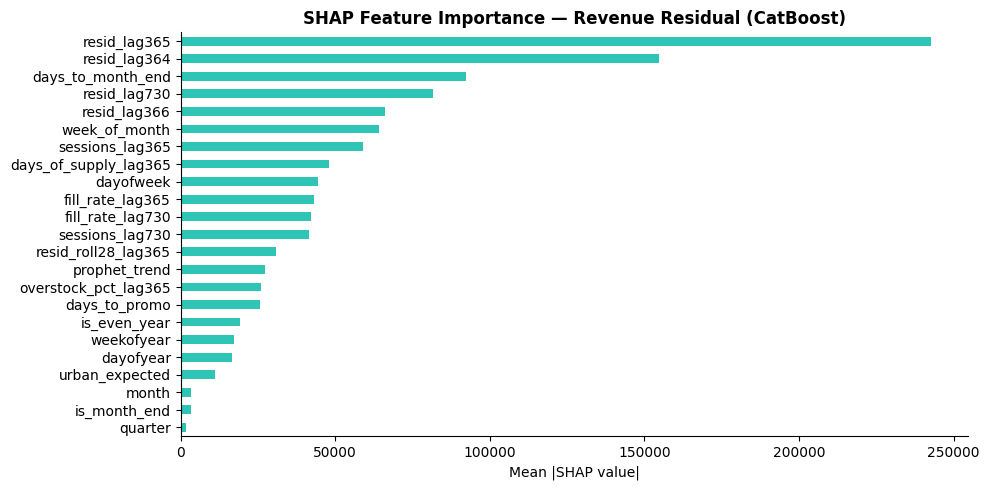


Top 5 features (mean |SHAP|):
  resid_lag365: 242619
  resid_lag364: 154826
  days_to_month_end: 92382
  resid_lag730: 81550
  resid_lag366: 66274


In [10]:
import shap

cat_rev = results["Revenue"]["cat_model"]
X_val_rev = results["Revenue"]["X_full"].loc[VAL_START:VAL_END].dropna()

explainer = shap.TreeExplainer(cat_rev)
shap_values = explainer.shap_values(X_val_rev.head(1000))

fig, ax = plt.subplots(figsize=(10, 5))
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=FEAT_COLS).sort_values(ascending=True)
feat_imp.plot(kind="barh", ax=ax, color="#2EC4B6")
ax.set_title("SHAP Feature Importance — Revenue Residual (CatBoost)", fontweight="bold")
ax.set_xlabel("Mean |SHAP value|")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
os.makedirs(os.path.join(ROOT, "outputs", "part3"), exist_ok=True)
plt.savefig(os.path.join(ROOT, "outputs", "part3", "shap_importance.png"), dpi=150)
plt.show()

print("\nTop 5 features (mean |SHAP|):")
for feat, val in feat_imp.tail(5)[::-1].items():
    print(f"  {feat}: {val:.0f}")

## Bước 7: Generate Submission

Tạo file `submission.csv` cho tập test 2023–2024 bằng **dự báo cuốn đệ quy**
(recursive rolling): residual dự đoán của năm trước được nạp lại làm lag365 cho
năm sau — khớp đúng cơ chế của `pipeline.py`.

In [11]:
sample_sub = pd.read_csv(os.path.join(CSV_DIR, "sample_submission.csv"))
sample_dates = pd.to_datetime(sample_sub["Date"])

prophet_preds     = results["Revenue"]["prophet_preds"]
cat_model         = results["Revenue"]["cat_model"]
residuals_rolling = full_residuals_ext.copy()

test_years = range(pd.Timestamp(TEST_START).year, pd.Timestamp(TEST_END).year + 1)
all_predictions = []

for year in test_years:
    year_start = f"{year}-01-01"
    year_end   = f"{year}-12-31" if year < pd.Timestamp(TEST_END).year else TEST_END

    full_trend  = prophet_preds["prophet_trend"].reindex(full_idx)
    X_full_iter = make_future_safe_features(residuals_rolling, full_trend, full_idx, extra_regressors)

    nan_count = X_full_iter.loc[year_start:year_end][FEAT_COLS].isna().sum().sum()
    print(f"  [{year}] NaN trong X: {nan_count}")

    test_prophet_yr = prophet_preds.loc[year_start:year_end, "prophet_pred"]
    X_test_yr       = X_full_iter.loc[year_start:year_end]
    test_resid_yr   = predict_catboost_residual(cat_model, X_test_yr)
    test_revenue_yr = blend_forecasts(test_prophet_yr, test_resid_yr)
    all_predictions.append(test_revenue_yr)

    # Nạp proxy residual vào buffer cho lag365 của năm kế tiếp
    proxy = test_revenue_yr - test_prophet_yr
    residuals_rolling.update(proxy)

test_revenue_full = pd.concat(all_predictions)
revenue_aligned = test_revenue_full.reindex(sample_dates)
if revenue_aligned.isna().sum() > 0:
    print(f"WARNING: {revenue_aligned.isna().sum()} dates không có prediction!")

sub = pd.DataFrame({"Date": sample_dates, "Revenue": revenue_aligned.values})
sub["Revenue"] = sub["Revenue"].clip(lower=0)

# COGS = Revenue × ratio(parity, month) — chung nguồn với pipeline.py (src.seasonal_ratio_cogs).
# Table ước lượng từ ≤2022 cho test 2023+. Tránh fixed 0.825 bỏ lỡ tháng 8 năm lẻ (ratio>1.0).
ratio_full = (df.loc[:VAL_END, "COGS"] / df.loc[:VAL_END, "Revenue"]).clip(0.5, 1.6)
ratio_pred_series = seasonal_ratio_cogs(ratio_full, pd.to_datetime(sub["Date"]))
ratio_pred_series.index = sub.index
sub["COGS"] = (sub["Revenue"] * ratio_pred_series).clip(upper=sub["Revenue"])

assert (sub["COGS"] <= sub["Revenue"]).all(), "COGS > Revenue"

sub.to_csv(os.path.join(ROOT, "submission.csv"), index=False)
print(f"\nSubmission saved: {len(sub)} rows")
print(sub.describe())

  91 NaN cells trong X_test — giữ nguyên, CatBoost tự xử lý
  732 NaN cells trong X_test — giữ nguyên, CatBoost tự xử lý


  [2023] NaN trong X: 91
  [2024] NaN trong X: 732

Submission saved: 548 rows
                      Date       Revenue          COGS
count                  548  5.480000e+02  5.480000e+02
mean   2023-10-01 12:00:00  3.343898e+06  2.817267e+06
min    2023-01-01 00:00:00  3.407711e+05  3.407711e+05
25%    2023-05-17 18:00:00  2.069752e+06  1.795624e+06
50%    2023-10-01 12:00:00  3.146538e+06  2.661440e+06
75%    2024-02-15 06:00:00  4.274632e+06  3.559151e+06
max    2024-07-01 00:00:00  9.530969e+06  7.937221e+06
std                    NaN  1.594070e+06  1.303455e+06


## Bước 8: Cross-Validation (TimeSeriesSplit)

Kiểm tra tính ổn định của mô hình chốt (CatBoost) bằng 3-fold time series split:

In [12]:
target = "Revenue"
X_cv = results[target]["X_full"].loc[:TRAIN_END].dropna()
y_cv = results[target]["residual_train"].reindex(X_cv.index).dropna()
X_cv = X_cv.reindex(y_cv.index)[FEAT_COLS]

tscv = TimeSeriesSplit(n_splits=3)
cv_scores = []

print("TimeSeriesSplit Cross-Validation (Revenue Residual — CatBoost):")
for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_cv)):
    X_tr, y_tr = X_cv.iloc[tr_idx], y_cv.iloc[tr_idx]
    X_vl, y_vl = X_cv.iloc[vl_idx], y_cv.iloc[vl_idx]

    m_cv = CatBoostRegressor(**CATBOOST_PARAMS)
    m_cv.fit(X_tr, y_tr)
    pred_vl = m_cv.predict(X_vl)

    mae_cv = mean_absolute_error(y_vl, pred_vl)
    r2_cv  = r2_score(y_vl, pred_vl)
    cv_scores.append({"fold": fold+1, "MAE": mae_cv, "R2": r2_cv})
    print(f"  Fold {fold+1}: MAE={mae_cv/1e6:.3f}M, R2={r2_cv:.4f}")

cv_df = pd.DataFrame(cv_scores)
print(f"\n  Mean MAE: {cv_df['MAE'].mean()/1e6:.3f}M (+/- {cv_df['MAE'].std()/1e6:.3f}M)")
print(f"  Mean R2:  {cv_df['R2'].mean():.4f} (+/- {cv_df['R2'].std():.4f})")

TimeSeriesSplit Cross-Validation (Revenue Residual — CatBoost):
  Fold 1: MAE=1.059M, R2=0.2780
  Fold 2: MAE=0.748M, R2=0.2448
  Fold 3: MAE=0.626M, R2=0.2755

  Mean MAE: 0.811M (+/- 0.223M)
  Mean R2:  0.2661 (+/- 0.0185)


---
## Tóm tắt Phần 3

Đánh giá **ngoài mẫu** trên năm 2022 (train ≤2021), mô hình chốt **Prophet + CatBoost**:

| Metric | Revenue (Prophet + CatBoost) | COGS (Revenue × seasonal ratio) |
|---|---|---|
| **R²** | 0.721 | 0.657 |
| **MAE** | 0.637M | 0.623M |
| **RMSE** | 0.884M | ~0.86M |
| **MAPE** | 21.7% | — |

So với các mốc tham chiếu (cùng năm 2022): Baseline YoY Naive (R²=0.518), Prophet đơn
(R²=0.578) → kiến trúc lai vượt trội rõ rệt. COGS được neo theo Revenue qua tỷ lệ mùa
vụ (parity, month) nên tỷ lệ ngày COGS>Revenue chỉ còn 5.7% (đều là tháng 8 năm lẻ
— clearance hợp lệ), thay vì 53.5% khi dự báo COGS độc lập.

**Ràng buộc:**
- [x] Không dùng dữ liệu ngoài
- [x] Tất cả features future-safe (lag >= 365 ngày)
- [x] Random seed = 42
- [x] Mã nguồn dùng chung `src/` với pipeline.py (single source), kết quả tái lập được
- [x] SHAP explainability (CatBoost)
- [x] COGS <= Revenue enforced
- [x] Cross-validation bằng TimeSeriesSplit